Excluir la celda de instalación a menos que sea necesario

In [1]:
# %pip install seaborn matplotlib numpy pandas networkx

# Acceso y limpieza de datos

In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
ruta = Path('..') / '..' / 'Fuentes/Studio_Ghibli.csv'
with open(ruta, 'r', encoding='utf-8') as f:
    df = pd.read_csv(f)

In [3]:
# Convertir la columna 'Duration' a minutos
def convertir_a_minutos(duracion):
	partes = duracion.split('h')
	horas = int(partes[0].strip())
	minutos = int(partes[1].replace('m', '').strip()) if len(partes) > 1 else 0
	return horas * 60 + minutos

df['Duration'] = df['Duration'].apply(convertir_a_minutos)

# Mapa de calor
Muestra el porcentaje de participación de los directores en cada uno de los géneros

In [4]:
# Crear un DataFrame con los géneros asociados a cada director
director_genres = df.melt(id_vars=['Director'], value_vars=['Genre 1', 'Genre 2', 'Genre 3'], 
						  var_name='Genre_Type', value_name='Genre').dropna()

# Contar la cantidad de veces que cada director ha trabajado en cada género
director_genre_counts = director_genres.groupby(['Director', 'Genre']).size().reset_index(name='Count')

# Calcular el total de géneros en los que ha trabajado cada director
director_total_genres = director_genre_counts.groupby('Director')['Count'].sum().reset_index(name='Total')

# Unir los datos para calcular el porcentaje
director_genre_percentage = pd.merge(director_genre_counts, director_total_genres, on='Director')
director_genre_percentage['Percentage'] = director_genre_percentage['Count'] / director_genre_percentage['Total']

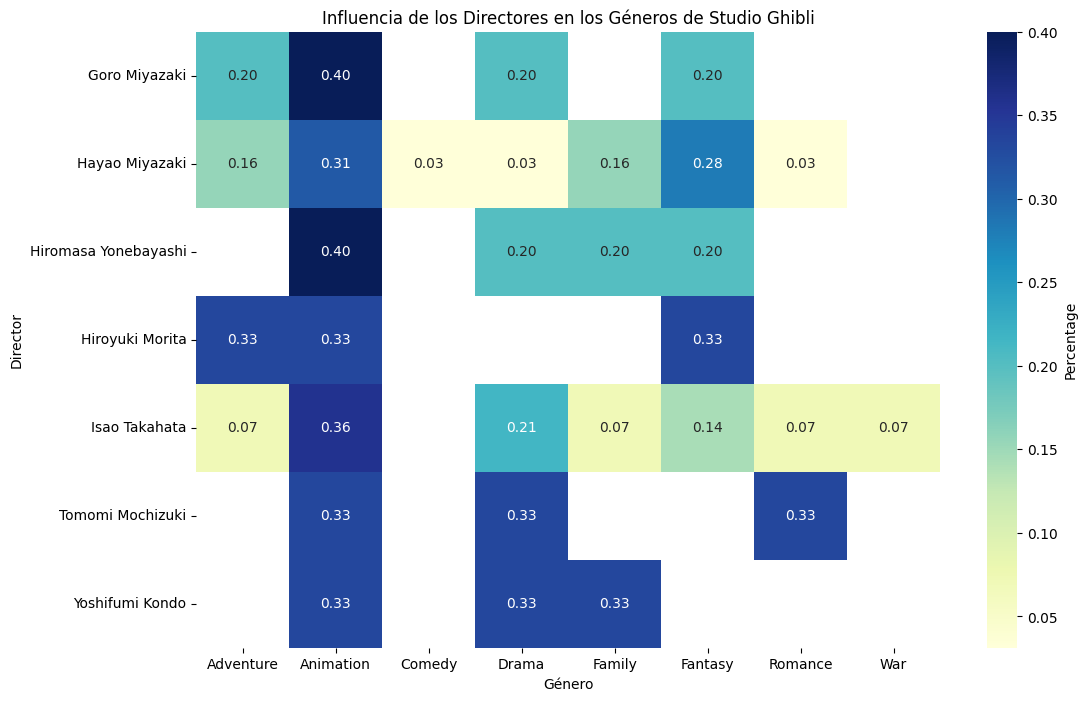

In [5]:
# Crear una tabla pivote para el mapa de calor
heatmap_data = director_genre_percentage.pivot(index="Director", columns="Genre", values="Percentage")

# Crear el mapa de calor
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'Percentage'})
plt.title("Influencia de los Directores en los Géneros de Studio Ghibli")
plt.xlabel("Género")
plt.ylabel("Director")
plt.show()

# Distribución de películas por género
Muestra como están distribuidas las películas entre los distintos géneros

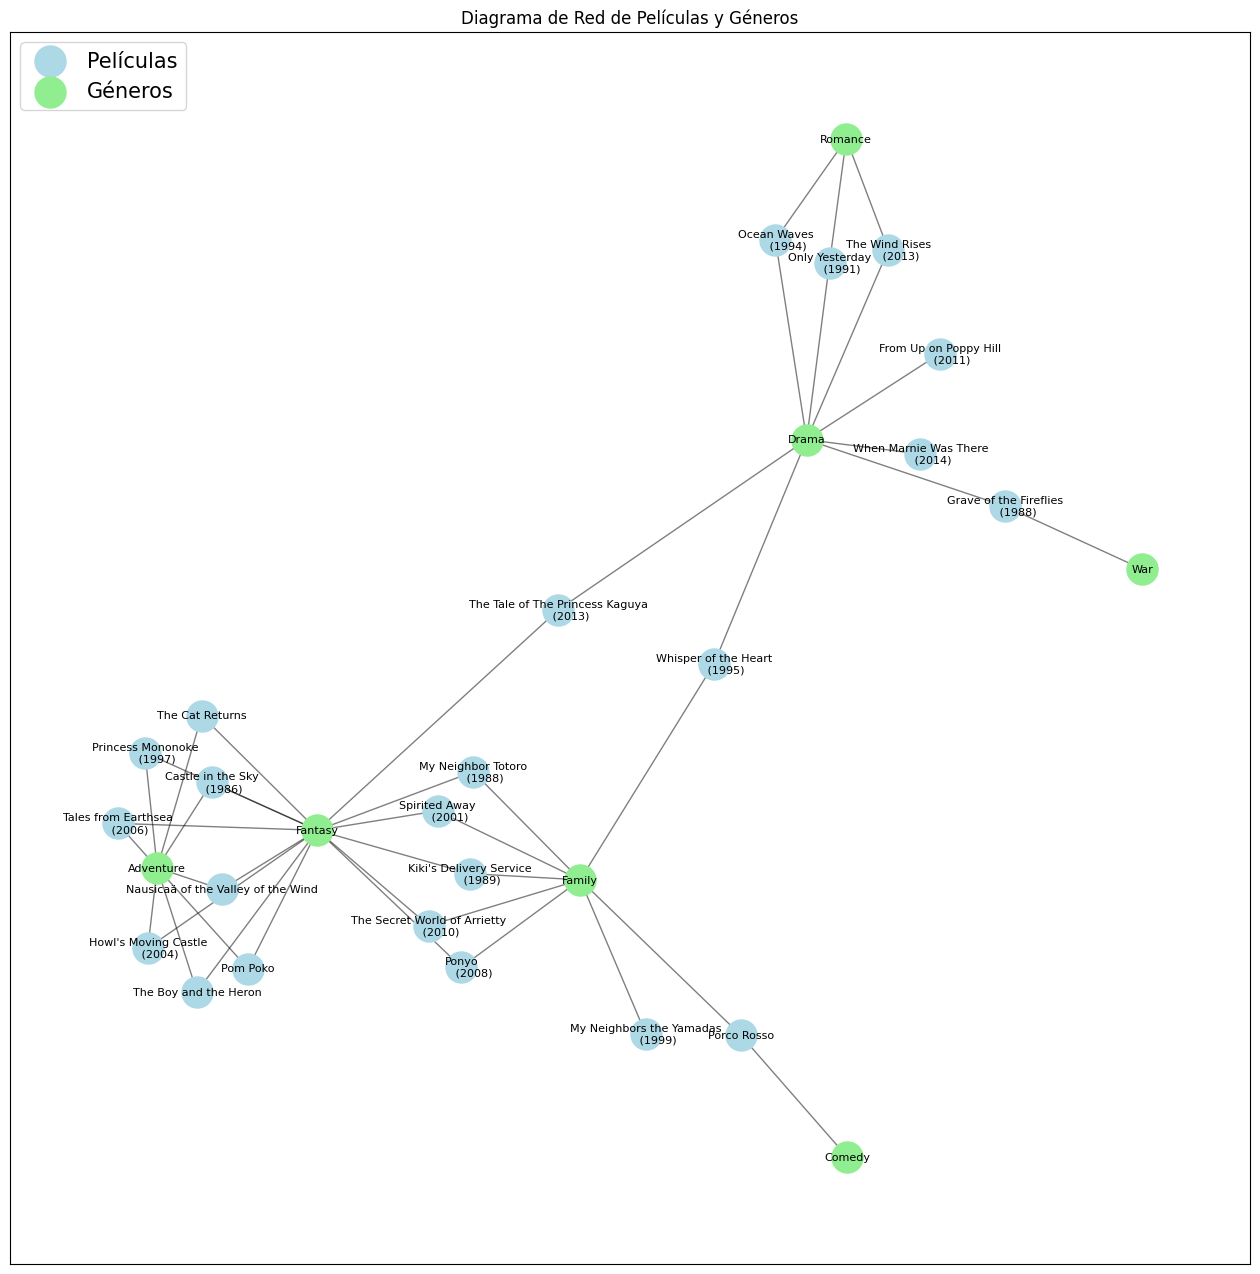

In [7]:
# Crear un DataFrame con las películas y sus géneros, excluyendo el género "Animation"
peliculas_generos = df.melt(id_vars=['Name'], value_vars=['Genre 1', 'Genre 2', 'Genre 3'], 
                            var_name='Genre_Type', value_name='Genre').dropna()

# Filtrar los géneros que no sean "Animation"
peliculas_generos = peliculas_generos[peliculas_generos['Genre'] != 'Animation']
# Crear un grafo
G = nx.Graph()

# Agregar nodos y aristas al grafo
for _, row in peliculas_generos.iterrows():
    pelicula = row['Name']
    genero = row['Genre']
    G.add_node(pelicula, type='pelicula')
    G.add_node(genero, type='genero')
    G.add_edge(pelicula, genero)

# Dibujar el grafo
plt.figure(figsize=(16, 16))
pos = nx.spring_layout(G, seed=42)  # Layout para la disposición de los nodos
nx.draw_networkx_nodes(G, pos, nodelist=[n for n, d in G.nodes(data=True) if d['type'] == 'pelicula'], 
                       node_color='lightblue', label='Películas', node_size=500)
nx.draw_networkx_nodes(G, pos, nodelist=[n for n, d in G.nodes(data=True) if d['type'] == 'genero'], 
                       node_color='lightgreen', label='Géneros', node_size=500)
nx.draw_networkx_edges(G, pos, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=8)

plt.title("Diagrama de Red de Películas y Géneros")
plt.legend(scatterpoints=1, loc='upper left', fontsize=15)
plt.show() 